# Customer Car Purchase Prediction
An exploratory marketing analytics case study using Logistic Regression.

**Question:** Can the supplied demographic and financial attributes distinguish car buyers from non-buyers?

This is an educational, retrospective classification exercise. The original dataset publisher, collection period, income unit, and category definitions have not been verified. It is not a validated forecast of future purchases or evidence of marketing savings.

## 1. Load and validate the data
Run all cells from a fresh kernel. Paths work from either the repository root or `notebooks/`.

In [1]:
from pathlib import Path
import json
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from IPython.display import display
from sklearn.model_selection import train_test_split, StratifiedKFold, cross_validate
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LogisticRegression
from sklearn.dummy import DummyClassifier
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score, ConfusionMatrixDisplay, RocCurveDisplay
ROOT = Path.cwd() if (Path.cwd() / 'data/calonpembeli_ch5.csv').exists() else Path.cwd().parent
assert (ROOT / 'data/calonpembeli_ch5.csv').exists(), 'Run from the repository root or notebooks folder.'
for folder in ['assets', 'reports']: (ROOT / folder).mkdir(exist_ok=True)
df = pd.read_csv(ROOT / 'data/calonpembeli_ch5.csv')
print('Raw shape:', df.shape)
display(df.head())
display(pd.DataFrame({'dtype':df.dtypes.astype(str), 'missing':df.isna().sum(), 'unique':df.nunique()}))
print('Duplicate IDs:', df.ID.duplicated().sum())
assert not df.ID.duplicated().any()
assert df.isna().sum().sum() == 0, 'Missing values require an explicit treatment policy.'
assert set(df.Beli_Mobil.unique()) == {0, 1}
invalid = ~df.Usia.between(18,100)
print('Excluded ages:', df.loc[invalid, 'Usia'].tolist())
df = df.loc[~invalid].copy()
print('Retained rows:', len(df))
print('Positive class share:', round(df.Beli_Mobil.mean(), 4))

Raw shape: (1000, 7)
Duplicate IDs: 0
Excluded ages: [164, 131]
Retained rows: 998
Positive class share: 0.6343


,ID,Usia,Status,Kelamin,Memiliki_Mobil,Penghasilan,Beli_Mobil
0,1,32,1,0,0,240,1
1,2,49,2,1,1,100,0
2,3,52,1,0,2,250,1
3,4,26,2,1,1,130,0
4,5,45,3,0,2,237,1


,dtype,missing,unique
ID,int64,0,1000
Usia,int64,0,44
Status,int64,0,4
Kelamin,int64,0,2
Memiliki_Mobil,int64,0,5
Penghasilan,int64,0,314
Beli_Mobil,int64,0,2


The adult-age validity rule (18–100) is a documented assumption, not an outlier threshold learned from the test data. Two implausible ages are excluded; no missing values are present. ID is excluded from modeling.

### Data dictionary
| Field | Treatment | Known limitation |
|---|---|---|
| ID | Identifier, excluded | No predictive interpretation |
| Usia | Numeric age | Presumed years |
| Status | One-hot encoded category | Meanings of codes 0–3 unknown |
| Kelamin | One-hot encoded category | Mapping of codes 0/1 unknown |
| Memiliki_Mobil | Numeric, provisional count | Values 0–4; confirm count versus category |
| Penghasilan | Numeric income | Currency and time unit unknown |
| Beli_Mobil | Binary target | 1 = purchase, 0 = no purchase; timing unknown |

## 2. Split before exploration and preprocessing
Keep 20% as a stratified holdout. Perform exploratory analysis and cross-validation using training data only. Scaling and encoding are fitted within the pipeline.

Training rows: 798 | Holdout rows: 200


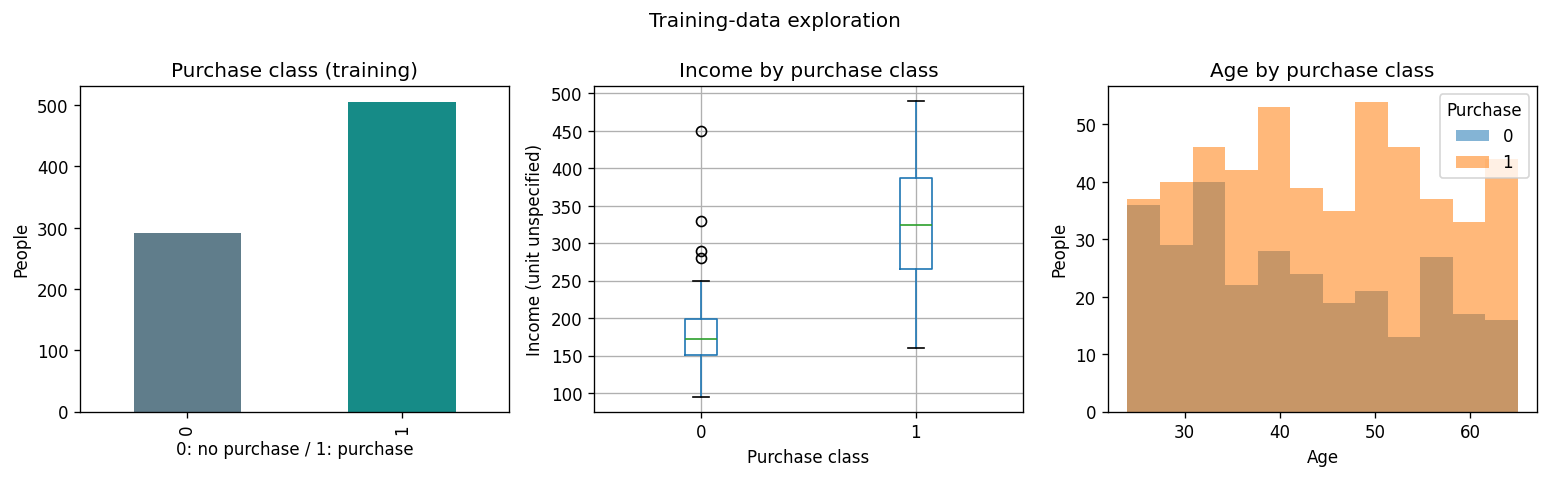

,Usia,Penghasilan,Memiliki_Mobil
Beli_Mobil,,,
0,39.5,172.0,1.0
1,44.0,324.0,1.0


In [2]:
features = ['Usia','Status','Kelamin','Memiliki_Mobil','Penghasilan']
X_train, X_test, y_train, y_test = train_test_split(df[features], df.Beli_Mobil, test_size=0.2, random_state=0, stratify=df.Beli_Mobil)
train = X_train.assign(Beli_Mobil=y_train)
print('Training rows:', len(train), '| Holdout rows:', len(X_test))
fig, axes = plt.subplots(1,3, figsize=(13,4))
train.Beli_Mobil.value_counts().sort_index().plot.bar(ax=axes[0], color=['#607D8B','#168B87'])
axes[0].set(title='Purchase class (training)', xlabel='0: no purchase / 1: purchase', ylabel='People')
train.boxplot(column='Penghasilan', by='Beli_Mobil', ax=axes[1]); axes[1].set(title='Income by purchase class', xlabel='Purchase class', ylabel='Income (unit unspecified)')
for label, group in train.groupby('Beli_Mobil'):
    axes[2].hist(group.Usia, bins=12, alpha=0.55, label=str(label))
axes[2].set(title='Age by purchase class', xlabel='Age', ylabel='People'); axes[2].legend(title='Purchase')
fig.suptitle('Training-data exploration'); fig.tight_layout()
fig.savefig(ROOT/'assets/eda.png', dpi=140, bbox_inches='tight'); plt.show()
display(train.groupby('Beli_Mobil')[['Usia','Penghasilan','Memiliki_Mobil']].median())

Compare the class counts and income distributions before interpreting accuracy. The grouped medians describe associations in this dataset; they do not establish causation. Income units and dataset provenance are still needed for a business interpretation.

## 3. Baseline and Logistic Regression
Treat Status as nominal because an ordered meaning is not documented. Standardize numeric inputs within each training fold. Keep the 0.5 threshold fixed; no test-set threshold optimization is performed.

In [3]:
numeric = ['Usia','Memiliki_Mobil','Penghasilan']
categorical = ['Status','Kelamin']
preprocessor = ColumnTransformer([('numeric', StandardScaler(), numeric), ('category', OneHotEncoder(drop='first', handle_unknown='ignore'), categorical)])
model = Pipeline([('prepare',preprocessor), ('model',LogisticRegression(max_iter=2000, random_state=0))])
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=0)
cv_scores = cross_validate(model, X_train, y_train, cv=cv, scoring={'auc':'roc_auc','f1':'f1','accuracy':'accuracy'})
cv_summary = pd.DataFrame({metric:{'mean':cv_scores['test_'+metric].mean(), 'std':cv_scores['test_'+metric].std()} for metric in ['auc','f1','accuracy']}).T
display(cv_summary.round(4))
baseline = DummyClassifier(strategy='most_frequent').fit(X_train,y_train)
model.fit(X_train,y_train)
def evaluate(estimator):
    pred = estimator.predict(X_test)
    probability = estimator.predict_proba(X_test)[:,1]
    return {'accuracy':accuracy_score(y_test,pred), 'precision':precision_score(y_test,pred,zero_division=0), 'recall':recall_score(y_test,pred), 'f1':f1_score(y_test,pred), 'roc_auc':roc_auc_score(y_test,probability)}
results = pd.DataFrame({'Majority baseline':evaluate(baseline), 'Logistic Regression':evaluate(model)}).T
display(results.round(4))
results.to_csv(ROOT/'reports/test_metrics.csv')
cv_summary.to_csv(ROOT/'reports/cv_metrics.csv')

,mean,std
auc,0.9809,0.0091
f1,0.9452,0.0181
accuracy,0.9310,0.0229


,accuracy,precision,recall,f1,roc_auc
Majority baseline,0.635,0.6350,1.000,0.7768,0.500
Logistic Regression,0.940,0.9675,0.937,0.9520,0.966


## 4. Holdout evaluation
ROC-AUC uses purchase probabilities, matching the ROC curve. Precision describes how often flagged buyers actually bought; recall describes how many recorded buyers were found. False positives could waste outreach effort; false negatives could miss opportunities. Actual costs are unknown, so no financial benefit is estimated.

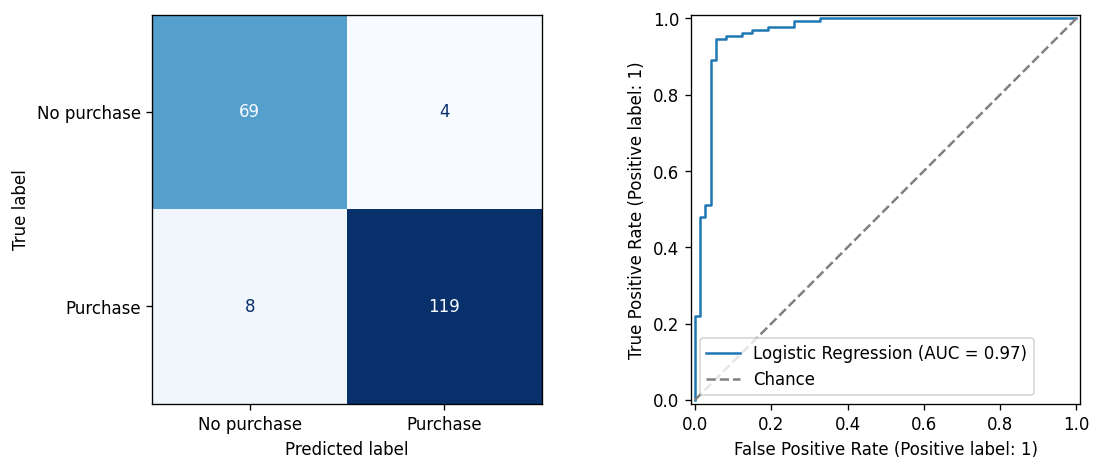

,feature,coefficient
6,category__Kelamin_1,-1.043
4,category__Status_2,-0.766
3,category__Status_1,-0.139
0,numeric__Usia,-0.127
5,category__Status_3,-0.105
1,numeric__Memiliki_Mobil,0.059
2,numeric__Penghasilan,5.105


In [4]:
probability = model.predict_proba(X_test)[:,1]
prediction = model.predict(X_test)
fig, axes = plt.subplots(1,2, figsize=(10,4))
ConfusionMatrixDisplay.from_predictions(y_test,prediction,ax=axes[0],colorbar=False,cmap='Blues',display_labels=['No purchase','Purchase'])
RocCurveDisplay.from_predictions(y_test,probability,ax=axes[1],name='Logistic Regression')
axes[1].plot([0,1],[0,1],'--',color='gray',label='Chance'); axes[1].legend()
fig.tight_layout(); fig.savefig(ROOT/'assets/evaluation.png',dpi=140,bbox_inches='tight'); plt.show()
coefficients = pd.DataFrame({'feature':model.named_steps['prepare'].get_feature_names_out(), 'coefficient':model.named_steps['model'].coef_[0]})
display(coefficients.sort_values('coefficient').round(3))

## 5. Interpretation and next steps
Numeric coefficients represent a one-training-standard-deviation change, holding other model inputs fixed. Category coefficients are relative to the dropped reference category. Neither coefficient size nor selection proves a causal driver or business importance.

The scores measure performance on a random holdout from this one dataset. They do not establish performance on future customers. Before deployment, verify data provenance, whether features were known before purchase, category meanings, income units, and demographic fairness. Ownership could leak the target if recorded after purchase; that cannot be resolved without source documentation.

Potential next steps: temporal validation on new customer records, cost-based threshold selection using validation data, calibration assessment, and subgroup evaluation. Any reduction in marketing spend must be measured through a separate business evaluation.

**Portfolio scope:** data validation, training-only exploration, preprocessing pipelines, baseline comparison, cross-validation, probability-based ROC-AUC, and responsible interpretation.